In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [179]:
resetar_banco = True
rodar_nm = True

In [218]:
data_phase = pd.read_csv('.\\database\\original-database\\dados_phase.csv')

valor = data_phase['Valor'].to_list()

aux = [valor[i:i+11] for i in range(len(valor) - 11 + 1)]

samples = pd.DataFrame(aux, columns=[f"sample({i})" for i in range(11)])
samples
phases = pd.DataFrame(data_phase['Tempo'][3:392].values, columns=['Phase'])
phases

data_phase = pd.concat((samples, phases), axis = 1)
data_phase.to_csv('.\\database\\data_phases.csv', index=False)


In [180]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")



Arquivo apagado: .\tests_nm\results\nm_occ0.2.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.5.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.7.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.9.csv
Limpeza da pasta .\tests_nm\results concluída com sucesso!


In [217]:
data = pd.read_csv('.\\database\\data_phases.csv')
# data = [pd.read_csv(r'database\data_occ0_2.csv'),
#         pd.read_csv(r'database\data_occ0_5.csv'),
#         pd.read_csv(r'database\data_occ0_7.csv'),
#         pd.read_csv(r'database\data_occ0_9.csv'),]

# phases = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
#           pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
#           pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
#           pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

# for i in range(4):
#     data[i]['phases'] = phases[i].values

#columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
#tol = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 20, 50, 100]
tol = [1]
ns = [-75, -50, -25, 0, 25, 50, 75]

In [182]:
def subtrai_estimada(sinalrecebido, resultado_neldermead):
    A = resultado_neldermead
    sample = sinalrecebido

    #Subtrai cada amplitude estimada do sinal recebido, considerando o padrão do sinal e ignorando a quarta amostra
    signalPattern = np.array([
            [A[0]*1.0    , A[1]*0.4524   , A[2]*0.0172   , 0             , 0             , 0             , 0],
            [A[0]*0.5633 , A[1]*1        , A[2]*0.4524   , A[3]*0.0172   , 0             , 0             , 0],
            [A[0]*0.1493 , A[1]*0.5633   , A[2]*1        , A[3]*0.4524   , A[4]*0.0172   , 0             , 0],
            [0           , 0             , 0             , 0             , 0             , 0             , 0],
            [0           , A[1]*0.0424   , A[2]*0.1493   , A[3]*0.5633   , A[4]*1        , A[5]*0.4524   , A[6]*0.0172],
            [0           , 0             , A[2]*0.0424   , A[3]*0.1493   , A[4]*0.5633   , A[5]*1        , A[6]*0.4524],
            [0           , 0             , 0             , A[3]*0.0424   , A[4]*0.1493   , A[5]*0.5633   , A[6]*1]
            ])
    
    for i in range(len(sinalrecebido)):
        sample = sample - signalPattern[i]
        #print(sample)
    
    return sample



In [183]:
def nelderMead(df, tol):
    def objectiveFunction( A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    def parada( xk):
        erro_atual = objectiveFunction(xk)
        if erro_atual < tol:
            raise StopIteration  
        
    sample4 = [] #Valor da amplitude do quarto sample para a solução encontrada
    iter_list = [] #Quatidade de iterações para a solução encontrada
    fun_list = [] #Valor da função objetivo para a solução encontrada
    ns_list = [] #Lista de ns para cada sample

    for samples in df:

        res = minimize(objectiveFunction, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        
        subtraida = subtrai_estimada(samples, res.x)
        sub_index = np.argmax(subtraida)
        print(f'{sub_index}, no tempo {ns[sub_index]}' )
        print(f'subtraida: {subtraida}')

        ns_list.append(ns[sub_index])
        sample4.append(res.x[3])
        iter_list.append(res.nit)
        fun_list.append(res.fun)

    return sample4, iter_list, fun_list, ns_list

In [184]:
def save_nm(sample4, iter_list, tol, occ, phase, fun_list, ns_list, amplitude):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    
            'TrueAmplitude': amplitude, 
            'EstimatedAmplitude': sample4,
            'PhaseSample(4)': phase, 
            'tolerance': tol,
            'function_values': fun_list,
            'ns': ns_list,
            'iterations': iter_list,})
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'PhaseSample(4)': phase,
            'tolerance': tol,
            'function_values': fun_list,
            'ns': ns_list,
            'iterations': iter_list
        })

    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [185]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            
            for t in tol: #quero iterar a partir do 10
                samples_data = np.array(data[i][columns[0:7]][:100])
                amplitudes_data = np.array(data[i][columns[7]][:100])
                phases_data = np.array(data[i][columns[8]][:100])

                sample4, iter_list, fun_list, ns_list = nelderMead(samples_data, t)
                save_nm(sample4, iter_list, t, occ_name[i], phases_data, fun_list, ns_list, amplitudes_data)
                k +=1
                print(f'Occupancy {occ_name[i][3:]} and tolerance {t} done, lacking {len(tol)*4 - k} combinations')

In [186]:
run_algorithm(data)

1, no tempo -50
subtraida: [-41.06998564  32.4255641   12.9256039   12.71882886   5.09525815
  14.34185526  -5.87281681]
1, no tempo -50
subtraida: [-35.48296365  38.66204133  -2.0327383   17.88069085   1.97452715
  10.20133654  -2.07418956]
1, no tempo -50
subtraida: [-23.48784302  26.3906955   -5.76706382  22.65724383  -5.40264111
  15.36702153  -3.1578163 ]
1, no tempo -50
subtraida: [-21.5428137   25.44071253  -1.21606692  17.34654488   1.29963493
  11.27598326  -2.23740255]
5, no tempo 50
subtraida: [-11.56129276  12.73180084  -0.78334188  20.42482191  -4.30640105
  20.63702068  -7.39380591]
5, no tempo 50
subtraida: [-11.97706338  10.71811576   3.9619164   15.88168823  -0.5986937
  21.81626794  -9.77025116]
5, no tempo 50
subtraida: [-14.61625162  14.37603007   3.96018491  14.69359051  -1.74507167
  36.75050672 -21.2123627 ]
1, no tempo -50
subtraida: [-20.34041204  28.14110621  -4.97378835  19.4205151   13.84080191
 -10.33267077   6.05255773]
3, no tempo 0
subtraida: [-16.436511

In [187]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

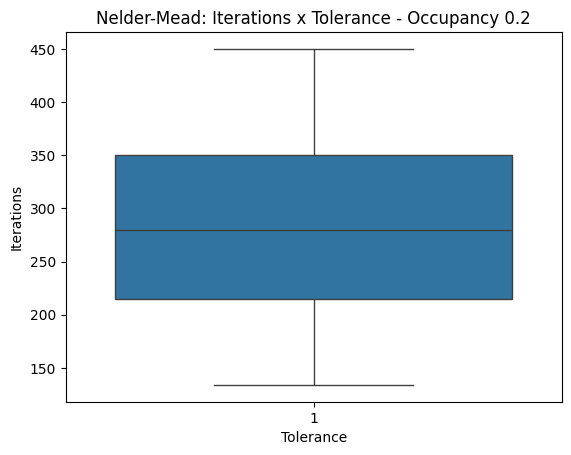

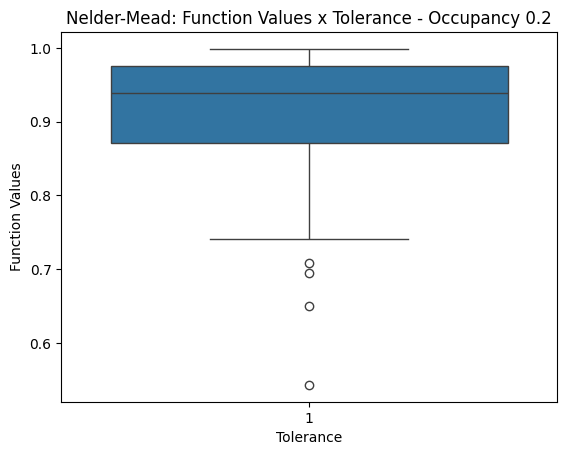

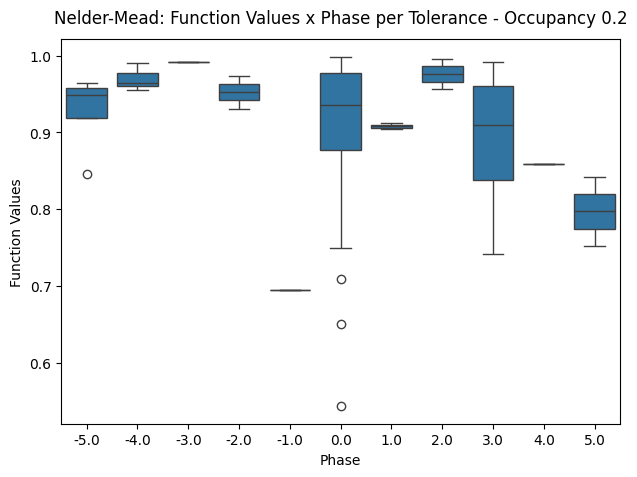

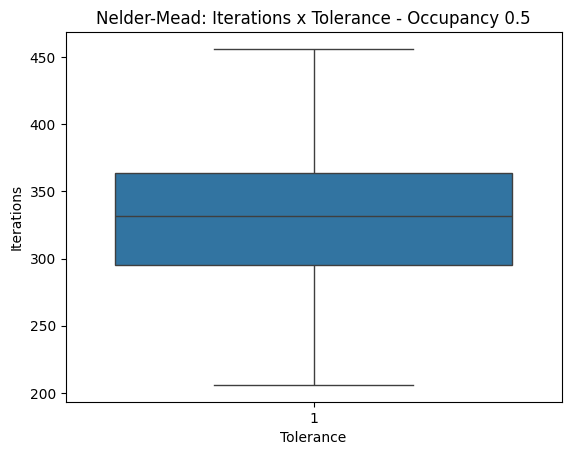

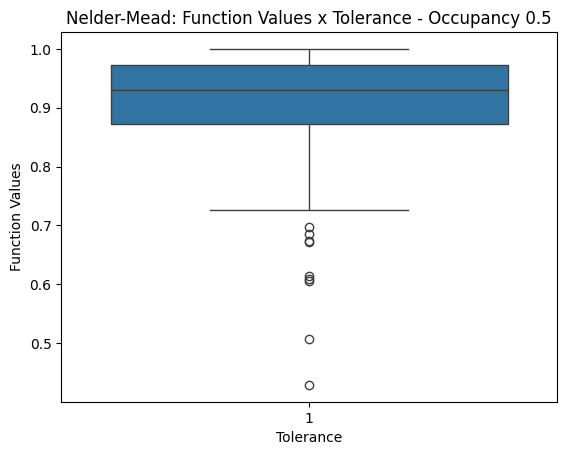

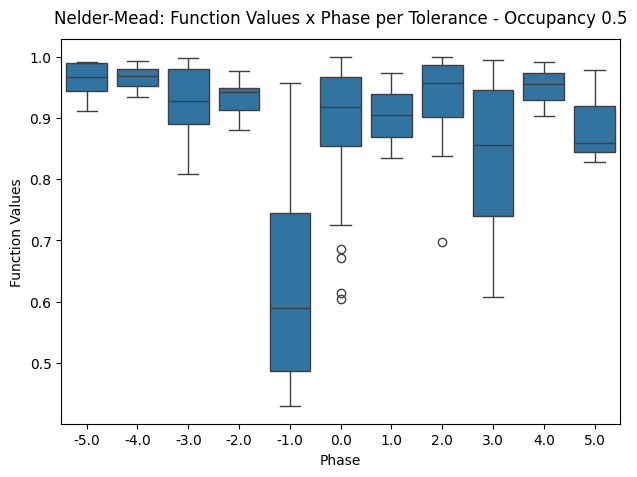

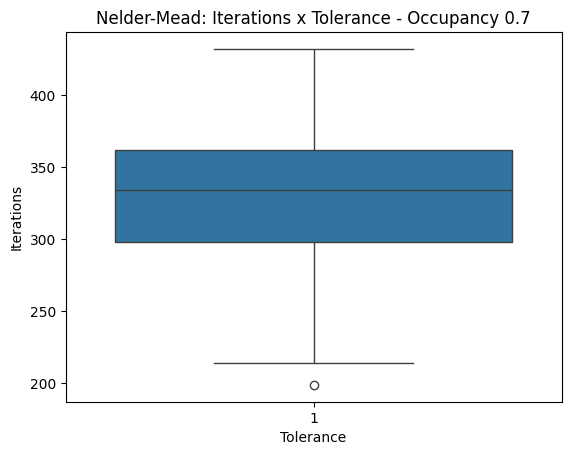

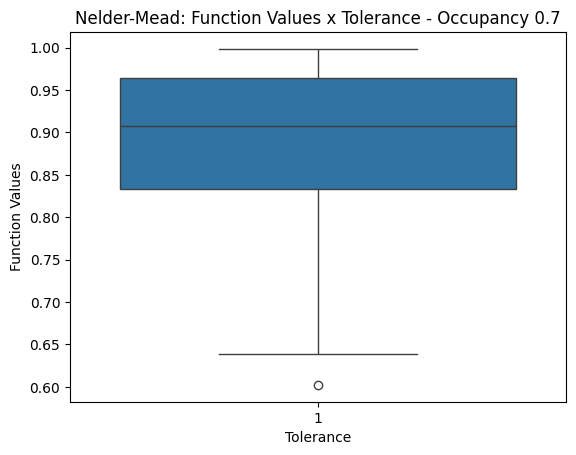

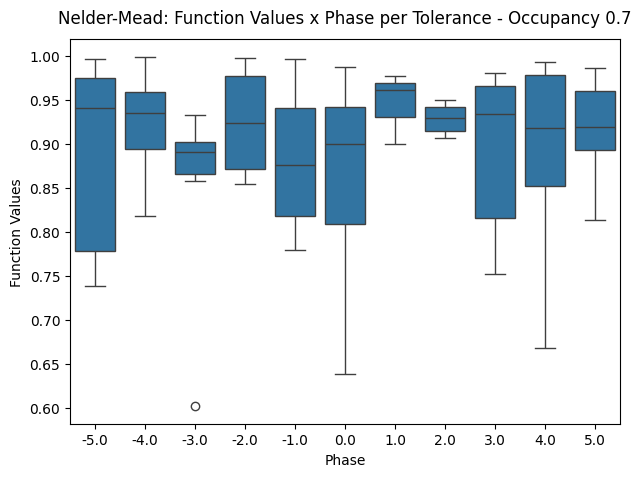

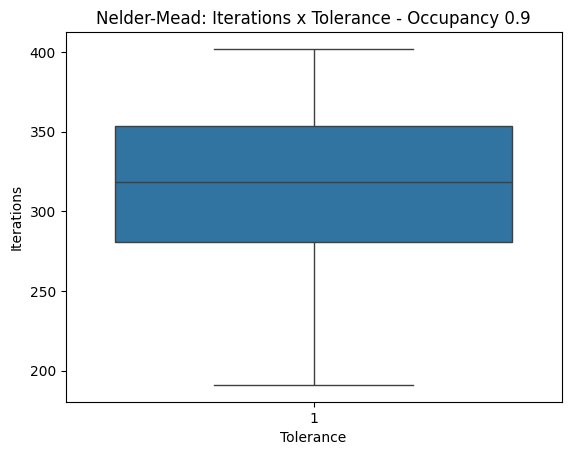

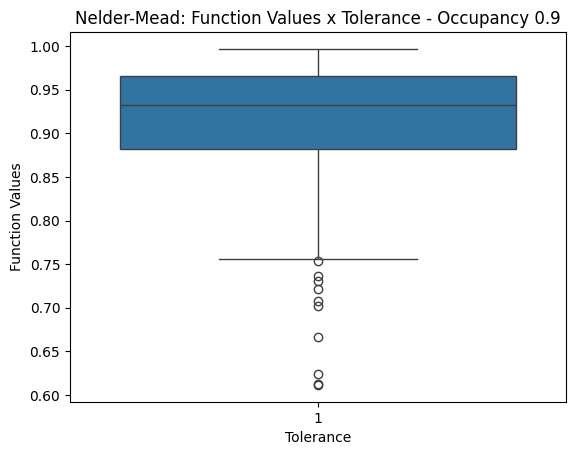

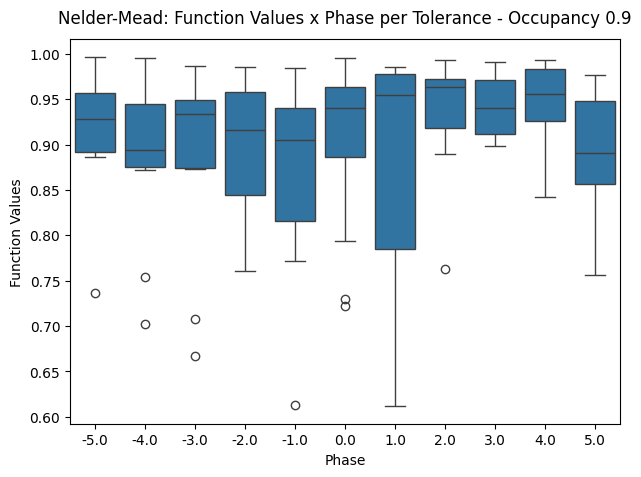

In [188]:
#Boxplot de tolerance por iterations
res = load_results()

for i in range(len(res)):
    ti = pd.DataFrame({'tolerance': res[i]['tolerance'], 'iterations': res[i]['iterations']})
    pf = pd.DataFrame({'phase': res[i]['PhaseSample(4)'], 'function_values': res[i]['function_values'], 'tolerance': res[i]['tolerance']})
    tf = pd.DataFrame({'tolerance': res[i]['tolerance'], 'function_values': res[i]['function_values']})
    
    sns.boxplot(x='tolerance', y='iterations', data=ti)
    plt.xlabel('Tolerance')
    plt.ylabel('Iterations')
    plt.title('Nelder-Mead: Iterations x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()

    sns.boxplot(x='tolerance', y='function_values', data=tf)
    plt.xlabel('Tolerance')
    plt.ylabel('Function Values')
    #plt.yscale('log')
    plt.title('Nelder-Mead: Function Values x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()

    sns.boxplot(x='phase', y='function_values', data=pf)
    plt.xlabel('Phase')
    plt.ylabel('Function Values')
    plt.title('Nelder-Mead: Function Values x Phase - Occupancy ' + occ_name[i][3:])
    plt.tight_layout()
    plt.title('Nelder-Mead: Function Values x Phase per Tolerance - Occupancy ' + occ_name[i][3:], y=1.02)
    plt.show()


In [189]:
#Media dos function values e iterações por tolerancia
for i in range(len(res)):
    tf = pd.DataFrame({'tolerance': res[i]['tolerance'], 'function_values': res[i]['function_values'], 'iterations': res[i]['iterations']})
    
    medias = tf.groupby('tolerance')[['function_values', 'iterations']].mean()
    
    print(f"--- Médias da Occupancy {occ_name[i][3:]} ---")
    print(f"{medias}\n")

--- Médias da Occupancy 0.2 ---
           function_values  iterations
tolerance                             
1                 0.911772      283.01

--- Médias da Occupancy 0.5 ---
           function_values  iterations
tolerance                             
1                 0.895897      331.63

--- Médias da Occupancy 0.7 ---
           function_values  iterations
tolerance                             
1                 0.890283      330.27

--- Médias da Occupancy 0.9 ---
           function_values  iterations
tolerance                             
1                 0.901216      314.65



In [190]:
#Calculo do desvio padrão do erro para cada tolerancia

# for i in range(len(res)):
#     res[i]['error'] = abs(res[i]['TrueAmplitude'] - res[i]['EstimatedAmplitude'])
#     desvio_padrao = res[i].groupby('tolerance')['error'].std()

#     plt.plot(desvio_padrao.index, desvio_padrao.values, marker='o', linestyle='-', label=f'Occupancy {occ_name[i][3:]}')
#     plt.xlabel('Tolerance')
#     plt.xscale('log')
#     plt.ylabel('Standard Deviation of Error')
#     plt.title(f'Desvio Padrão do Erro para Occupancy {occ_name[i][3:]}')
#     plt.legend()

#     print(f"--- Desvio Padrão do Erro para Occupancy {occ_name[i][3:]} ---")
#     print(f"{desvio_padrao}\n")

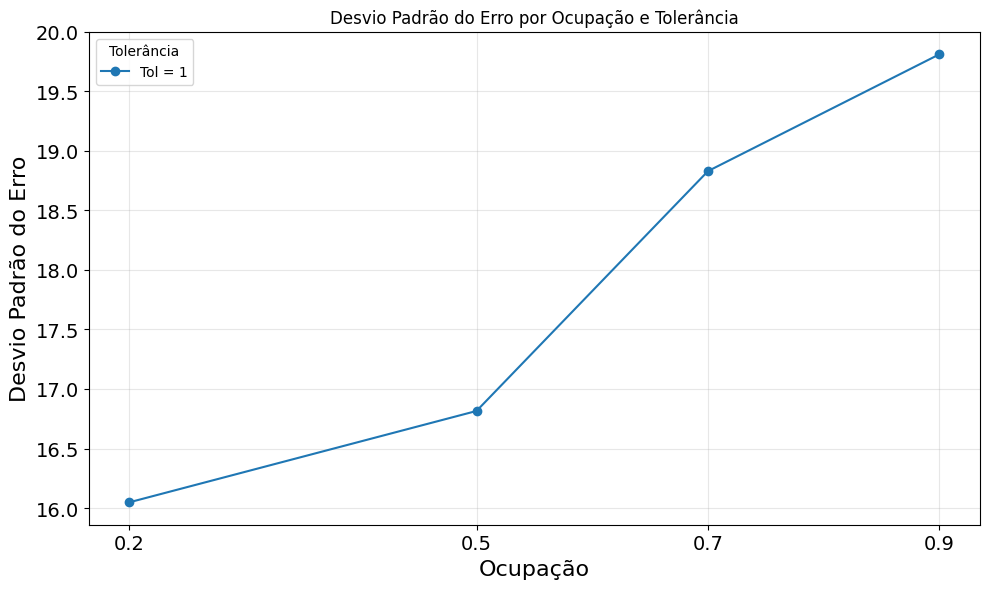

Tolerância 1: occ 0.2: 16.047925  occ 0.5: 16.815369  occ 0.7: 18.830624  occ 0.9: 19.812389


In [191]:
# Desvio padrão do erro por ocupação, com uma linha por tolerância
occs = [0.2, 0.5, 0.7, 0.9]

std_por_tol_occ = {}
for i in range(len(res)):
    res[i]['error'] = abs(res[i]['TrueAmplitude'] - res[i]['EstimatedAmplitude'])
    std_por_tol = res[i].groupby('tolerance')['error'].std()
    for t, val in std_por_tol.items():
        if t not in std_por_tol_occ:
            std_por_tol_occ[t] = []
        std_por_tol_occ[t].append(val)

plt.figure(figsize=(10, 6))
for t, vals in std_por_tol_occ.items():
    plt.plot(occs, vals, marker='o', linestyle='-', label=f'Tol = {t}')

plt.xlabel('Ocupação', fontsize=16)
plt
plt.ylabel('Desvio Padrão do Erro', fontsize=16)
plt.title('Desvio Padrão do Erro por Ocupação e Tolerância')
plt.xticks(occs)
plt.legend(title='Tolerância')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

for t, vals in std_por_tol_occ.items():
    print(f"Tolerância {t}:", "  ".join(f"occ {o}: {v:.6f}" for o, v in zip(occs, vals)))

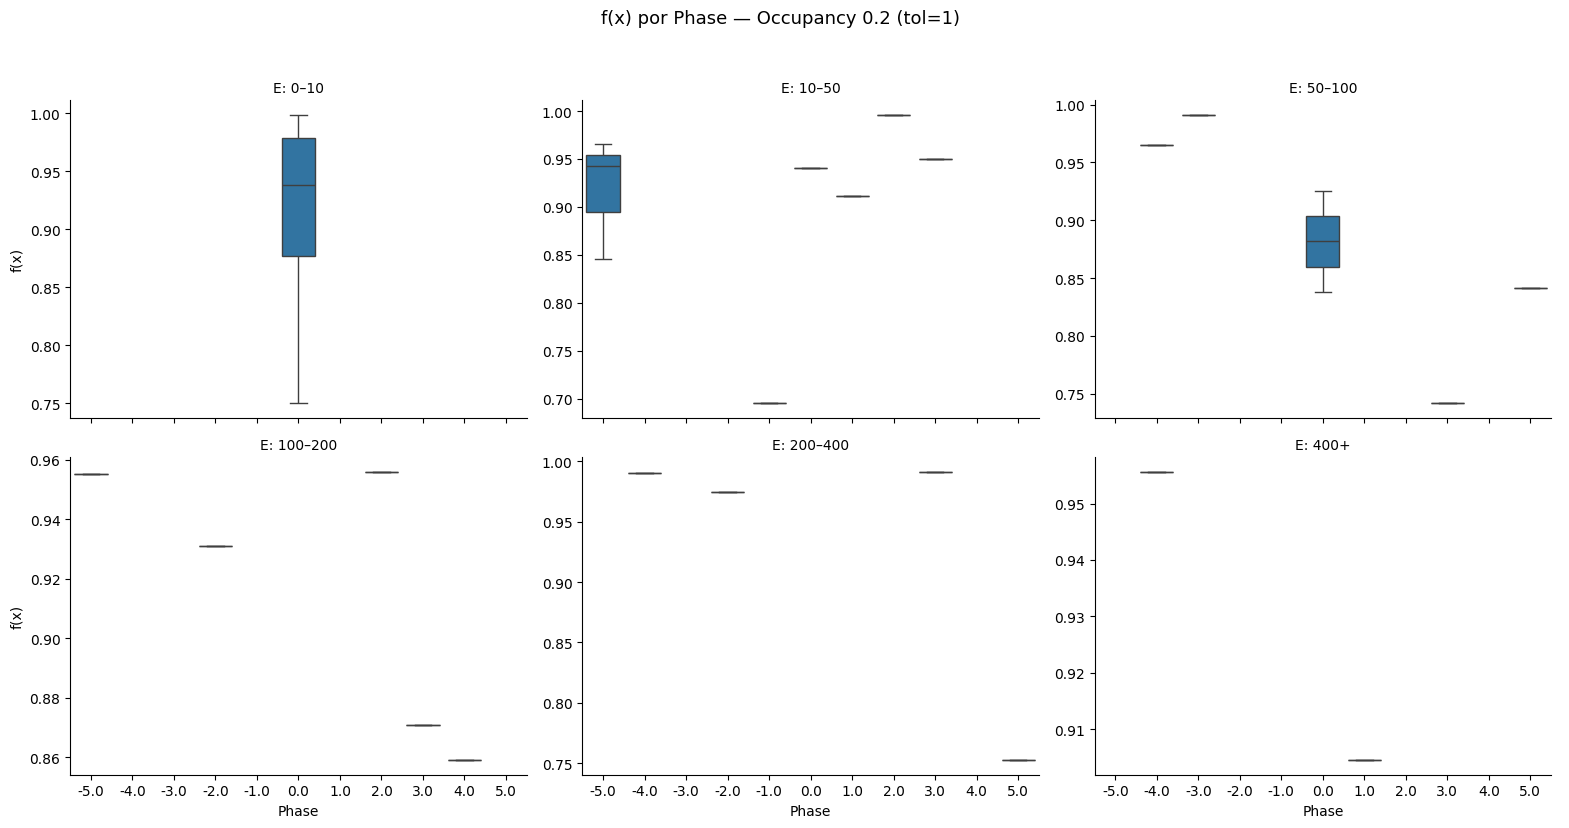

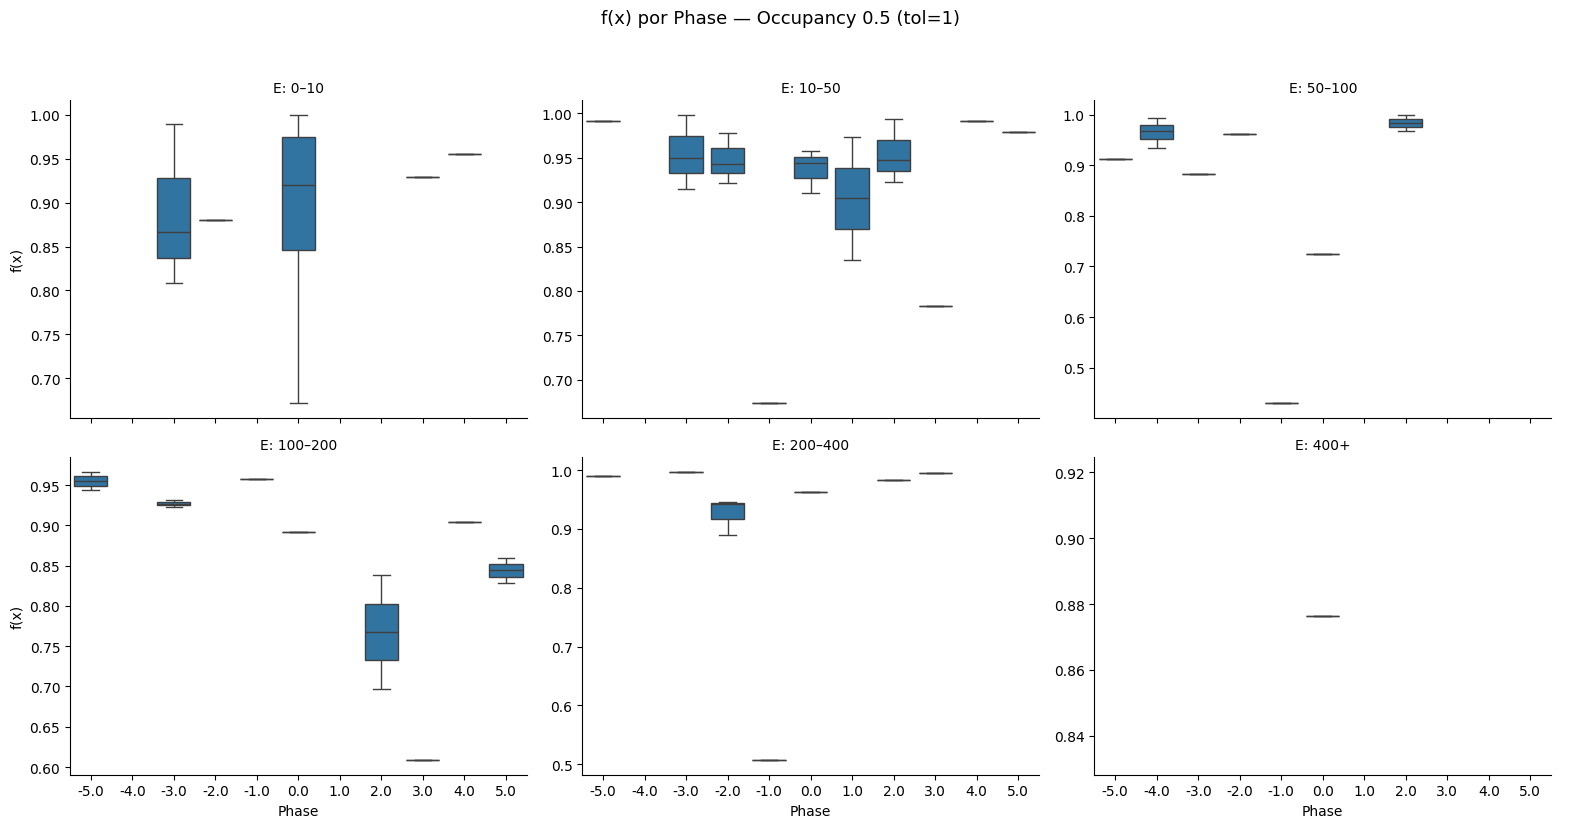

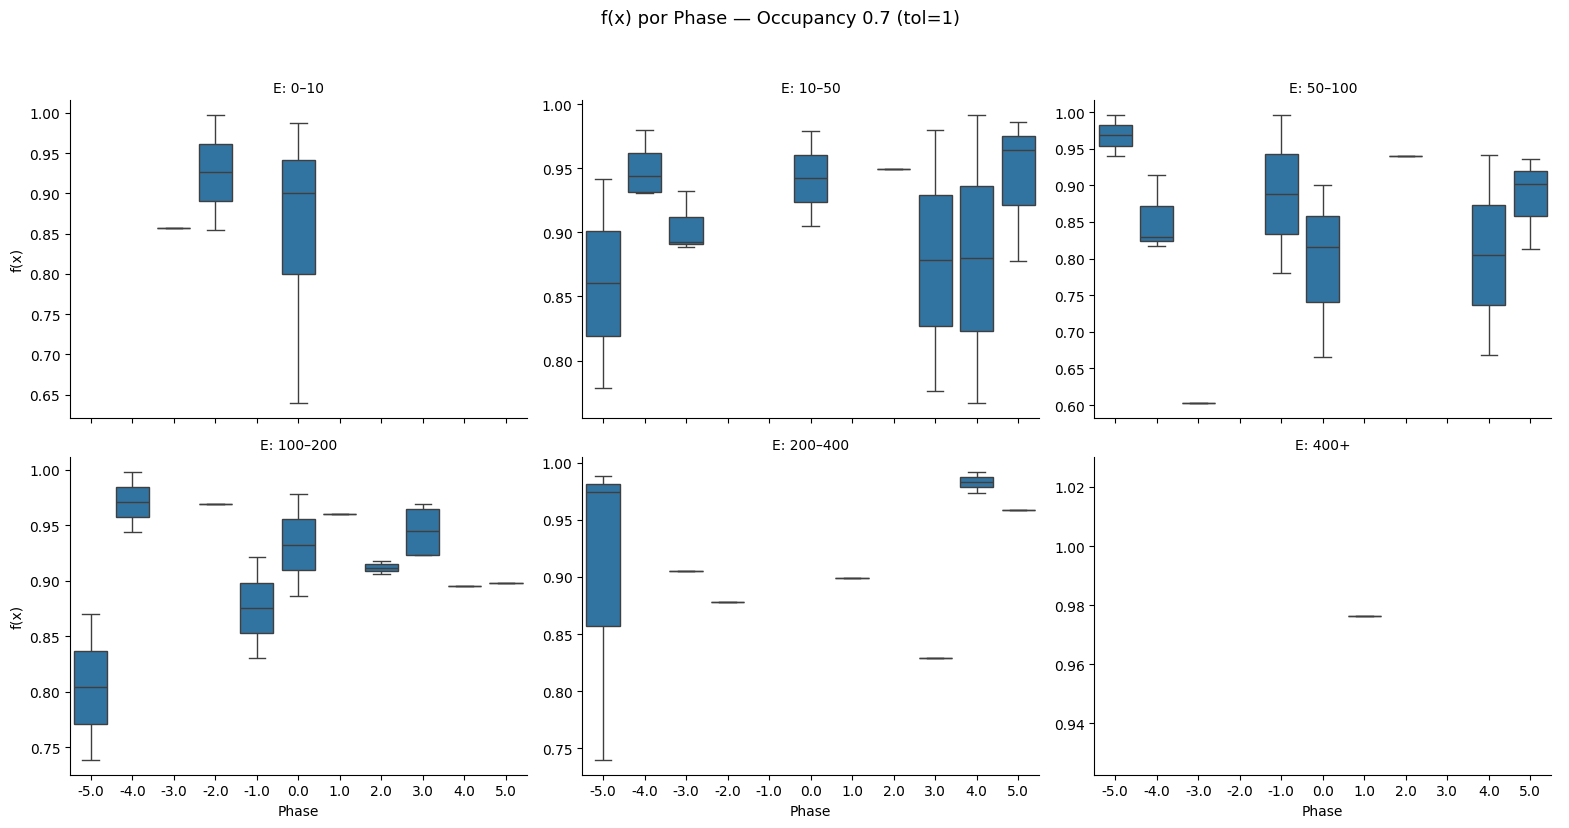

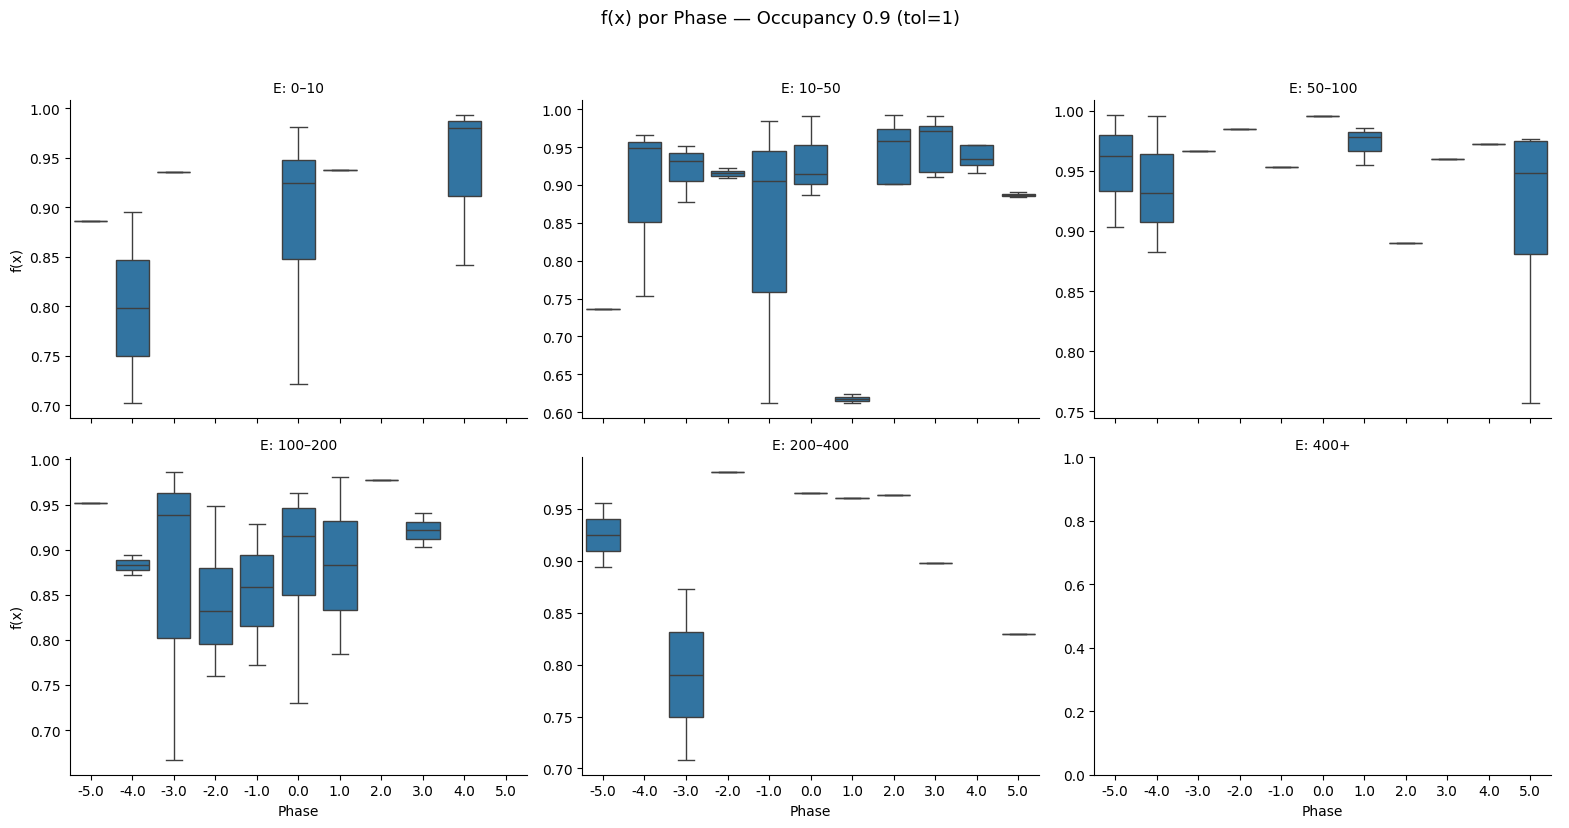

In [192]:
res = load_results()

bins   = [0, 10, 50, 100, 200, 400, np.inf]
labels = ['0–10', '10–50', '50–100', '100–200', '200–400', '400+']

tol_filtro = 1

for i in range(len(res)):
    df = res[i].copy()
    df = df[df['tolerance'] == tol_filtro]

    df['faixa_energia'] = pd.cut(
        df['TrueAmplitude'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    #df = df.dropna(subset=['faixa_energia'])  # remove E fora do intervalo [0, 400]

    g = sns.catplot(
        data=df,
        x='PhaseSample(4)',
        y='function_values',
        col='faixa_energia',
        col_wrap=3,
        kind='box',
        height=4,
        aspect=1.3,
        sharey=False,
        showfliers=False,
    )
    g.set_axis_labels('Phase', 'f(x)')
    g.set_titles(col_template='E: {col_name}')
    g.fig.suptitle(
        f'f(x) por Phase — Occupancy {occ_name[i][3:]} (tol={tol_filtro})',
        y=1.03, fontsize=13
    )
    plt.tight_layout()
    plt.show()
